In [15]:
import pandas as pd

# ===================== 读取表达矩阵 =====================
expr = pd.read_csv(
    "GSE63142_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
)
print("矩阵读取成功：", expr.shape)

# ===================== 读取真正的分组信息 =====================
groups = []

with open("GSE63142_series_matrix.txt", "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            parts = line.strip().split("\t")[1:]
            for p in parts:
                p = p.lower()
                if "control" in p:
                    groups.append("Control")
                elif "severe" in p:
                    groups.append("Severe_Asthma")
                else:
                    groups.append("Asthma")
            break

# ===================== 输出结果 =====================
print("\n真实分组结果：")
print(pd.Series(groups).value_counts())

矩阵读取成功： (30889, 155)

真实分组结果：
Severe_Asthma    128
Control           27
Name: count, dtype: int64


In [20]:
import pandas as pd
import numpy as np

# ===================== 读取表达矩阵 =====================
expr = pd.read_csv(
    "GSE63142_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
)
print("表达矩阵读取成功：", expr.shape)

# ===================== 从文档提取真实分组 =====================
groups = []

with open("GSE63142_series_matrix.txt", "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")[1:]
            for p in parts:
                if "control" in p:
                    groups.append("Control")
                elif "not severe asthmatic" in p:
                    groups.append("Mild_Moderate_Asthma")
                elif "severe asthmatic" in p:
                    groups.append("Severe_Asthma")
            break

# ===================== 输出分组结果 =====================
print("\n精准分组统计：")
print(pd.Series(groups).value_counts())
# control → 正常
# not severe asthmatic → 轻中度哮喘
# severe asthmatic → 重度哮喘

表达矩阵读取成功： (30889, 155)

精准分组统计：
Mild_Moderate_Asthma    72
Severe_Asthma           56
Control                 27
Name: count, dtype: int64


In [22]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler

# ===================== 1. 读取数据 =====================
expr = pd.read_csv(
    "GSE63142_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
)

# =====================  关键修复：log2 标准化 =====================
expr = np.log2(expr + 1)  

print("表达矩阵读取 + log2 标准化完成：", expr.shape)

# ===================== 2. 精准分组 =====================
groups = []
with open("GSE63142_series_matrix.txt", "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")[1:]
            for p in parts:
                if "control" in p:
                    groups.append("Control")
                elif "not severe asthmatic" in p:
                    groups.append("Mild_Moderate_Asthma")
                elif "severe asthmatic" in p:
                    groups.append("Severe_Asthma")
            break

print("\n 分组：")
print(pd.Series(groups).value_counts())

# ===================== 3. 差异分析 =====================
control_idx = [i for i, g in enumerate(groups) if g == "Control"]
asthma_idx = [i for i, g in enumerate(groups) if g != "Control"]

control_data = expr.iloc[:, control_idx]
asthma_data = expr.iloc[:, asthma_idx]

results = []
for gene in expr.index:
    ctrl = control_data.loc[gene]
    asth = asthma_data.loc[gene]

    t_stat, p_val = stats.ttest_ind(ctrl, asth, equal_var=False)
    log2fc = np.mean(asth) - np.mean(ctrl)

    results.append({
        "gene": gene,
        "log2FC": log2fc,
        "p_value": p_val
    })

res_df = pd.DataFrame(results)
res_df["adj_p"] = multipletests(res_df["p_value"], method="fdr_bh")[1]

# 放宽一点阈值，更容易出结果
res_df["significant"] = (abs(res_df["log2FC"]) > 0.5) & (res_df["adj_p"] < 0.05)

print("\n差异分析完成！")
up = sum((res_df["log2FC"] > 0.5) & (res_df["adj_p"] < 0.05))
down = sum((res_df["log2FC"] < -0.5) & (res_df["adj_p"] < 0.05))
print(f"显著上调：{up}")
print(f"显著下调：{down}")

表达矩阵读取 + log2 标准化完成： (30889, 155)

✅ 分组：
Mild_Moderate_Asthma    72
Severe_Asthma           56
Control                 27
Name: count, dtype: int64

差异分析完成！
显著上调：0
显著下调：0


数据读取完成： (30889, 155)


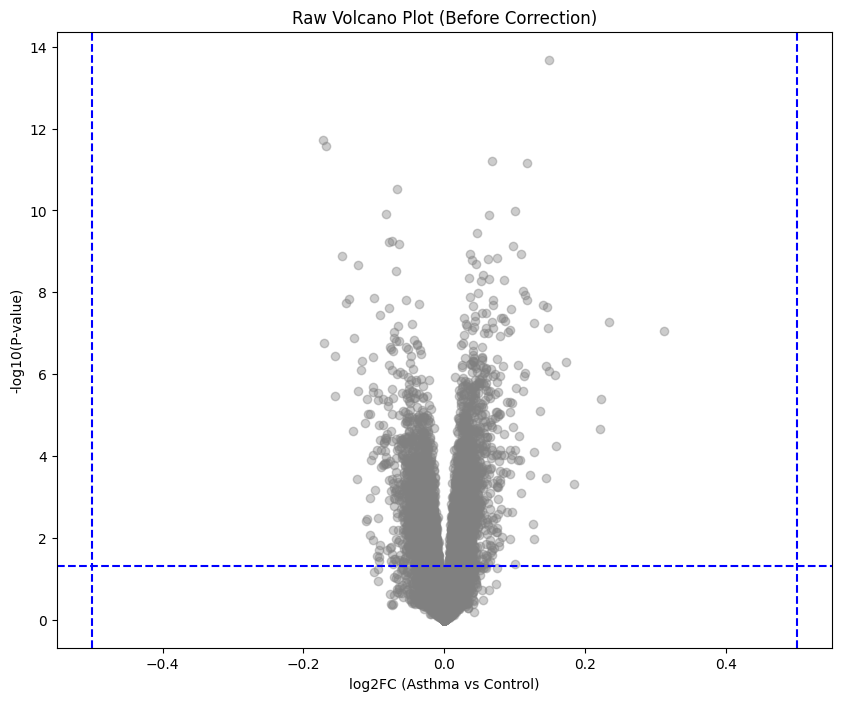

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取并标准化数据
expr = pd.read_csv(
    "GSE63142_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
)
expr = np.log2(expr + 1)  # 芯片数据必须这一步
print("数据读取完成：", expr.shape)

# 2. 读取分组
groups = []
with open("GSE63142_series_matrix.txt", "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")[1:]
            for p in parts:
                if "control" in p:
                    groups.append("Control")
                else:
                    groups.append("Asthma")
            break

# 3. 计算log2FC和p值
control_idx = [i for i, g in enumerate(groups) if g == "Control"]
asthma_idx = [i for i, g in enumerate(groups) if g != "Control"]

ctrl = expr.iloc[:, control_idx]
asth = expr.iloc[:, asthma_idx]

# 直接计算每个基因的差异
log2fc = np.mean(asth, axis=1) - np.mean(ctrl, axis=1)
_, pvals = stats.ttest_ind(asth, ctrl, axis=1, equal_var=False)

# 4. 先画一个“原始火山图”，看分布
plt.figure(figsize=(10, 8))
plt.scatter(log2fc, -np.log10(pvals), alpha=0.4, color="gray")
plt.axvline(x=0.5, color="blue", linestyle="--")
plt.axvline(x=-0.5, color="blue", linestyle="--")
plt.axhline(y=-np.log10(0.05), color="blue", linestyle="--")
plt.xlabel("log2FC (Asthma vs Control)")
plt.ylabel("-log10(P-value)")
plt.title("Raw Volcano Plot (Before Correction)")
plt.show()

数据读取完成： (30889, 155)


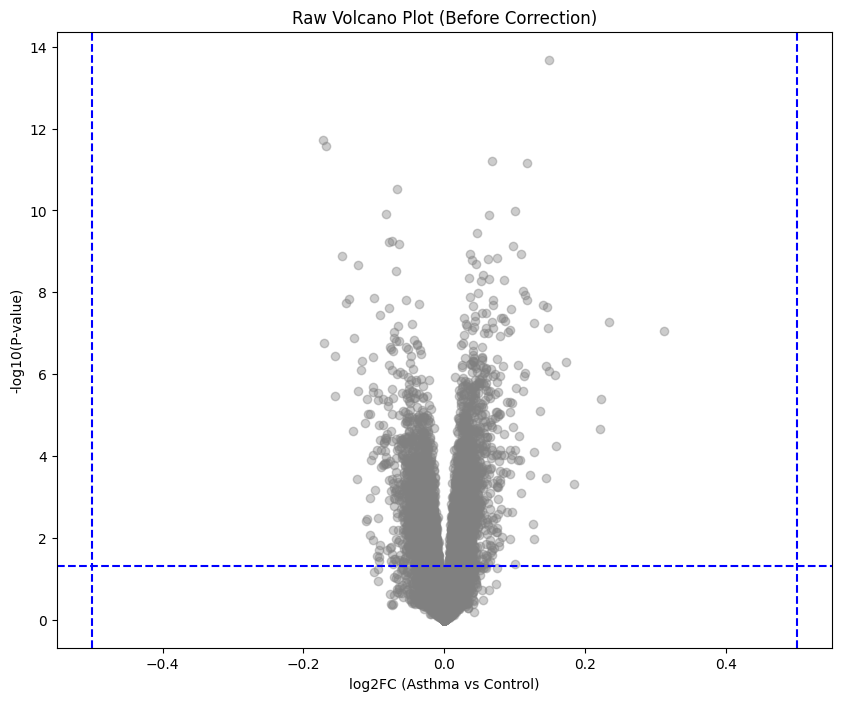

C:\Users\q_wr2\.conda\envs\Exercise\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\q_wr2\.conda\envs\Exercise\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1200x800 with 0 Axes>

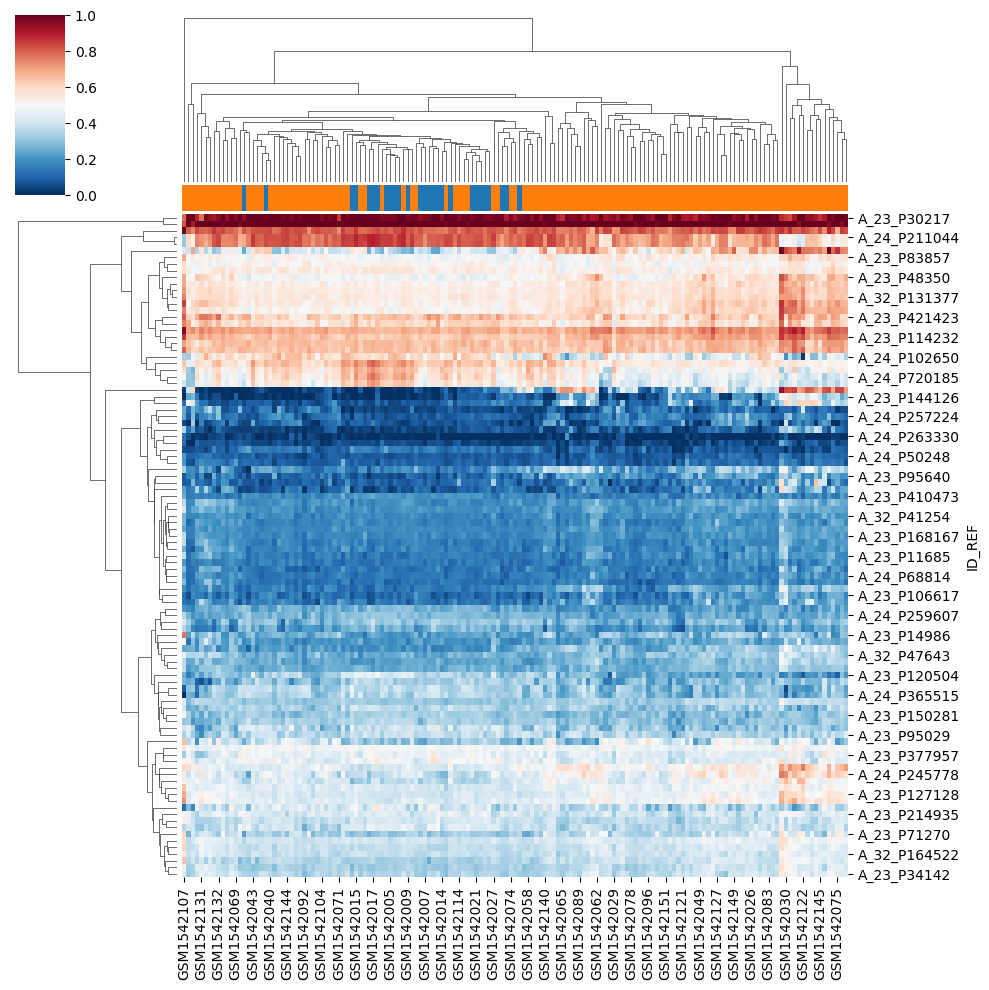

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取并标准化数据
expr = pd.read_csv(
    "GSE63142_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
)
expr = np.log2(expr + 1)
print("数据读取完成：", expr.shape)

# 2. 读取分组
groups = []
with open("GSE63142_series_matrix.txt", "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")[1:]
            for p in parts:
                if "control" in p:
                    groups.append("Control")
                else:
                    groups.append("Asthma")
            break

# 3. 计算log2FC和p值
control_idx = [i for i, g in enumerate(groups) if g == "Control"]
asthma_idx = [i for i, g in enumerate(groups) if g != "Control"]

ctrl = expr.iloc[:, control_idx]
asth = expr.iloc[:, asthma_idx]

# 直接计算每个基因的差异
log2fc = np.mean(asth, axis=1) - np.mean(ctrl, axis=1)
_, pvals = stats.ttest_ind(asth, ctrl, axis=1, equal_var=False)

# 4. 先画一个“原始火山图”，看分布
plt.figure(figsize=(10, 8))
plt.scatter(log2fc, -np.log10(pvals), alpha=0.4, color="gray")
plt.axvline(x=0.5, color="blue", linestyle="--")
plt.axvline(x=-0.5, color="blue", linestyle="--")
plt.axhline(y=-np.log10(0.05), color="blue", linestyle="--")
plt.xlabel("log2FC (Asthma vs Control)")
plt.ylabel("-log10(P-value)")
plt.title("Raw Volcano Plot (Before Correction)")
plt.show()

res_df = pd.DataFrame({"gene": expr.index, "log2FC": log2fc, "p_value": pvals})
res_df["adj_p"] = multipletests(res_df["p_value"], method="fdr_bh")[1]

# 取p值最小的前100个基因
top100 = res_df.sort_values("adj_p").head(100)["gene"].tolist()
top_expr = expr.loc[top100, :]

# 绘制热图
plt.figure(figsize=(12, 8))
sns.clustermap(top_expr, col_colors=["#1f77b4" if g=="Control" else "#ff7f0e" for g in groups], cmap="RdBu_r", standard_scale=1)
plt.show()

C:\Users\q_wr2\.conda\envs\Exercise\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


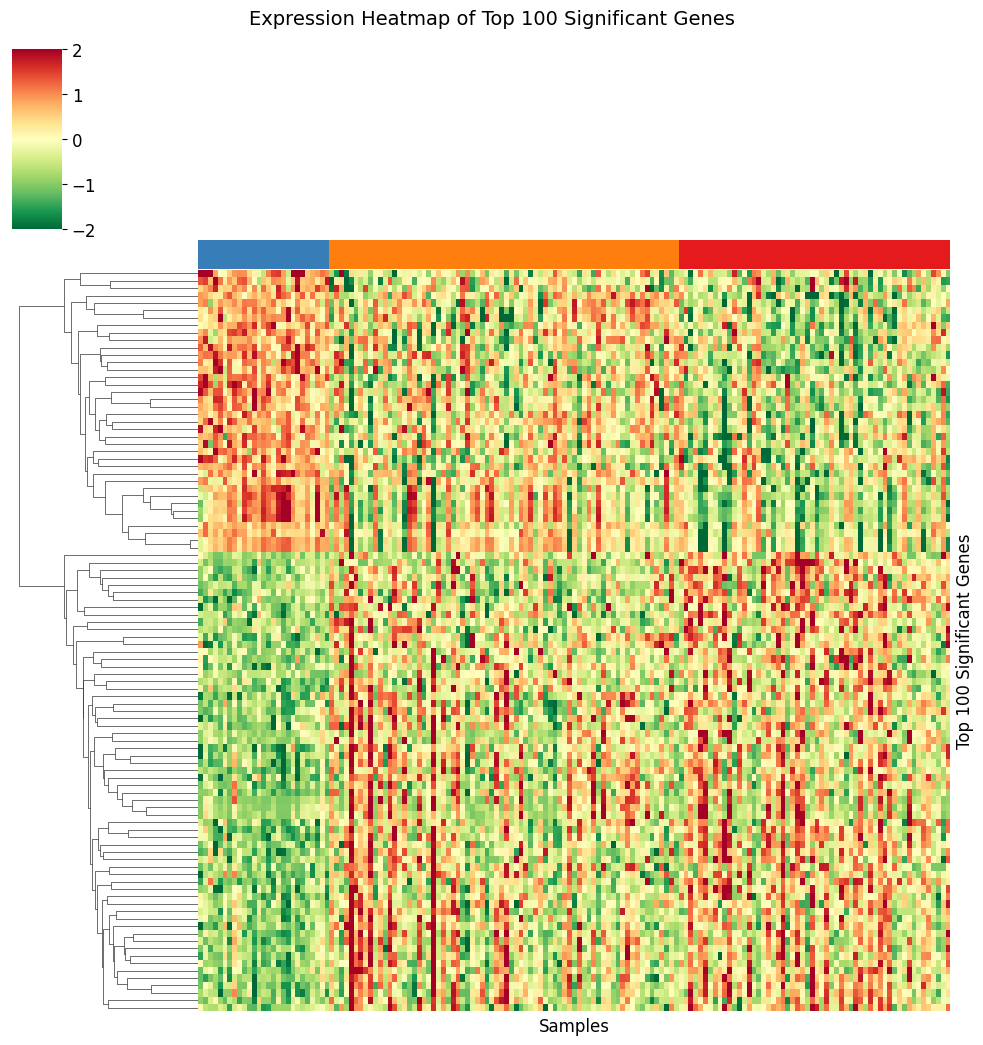

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ===================== 1. 读取数据 =====================
expr = pd.read_csv(
    "GSE63142_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
)
expr = np.log2(expr + 1)

# ===================== 2. 精准分组 =====================
groups = []
with open("GSE63142_series_matrix.txt", "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")[1:]
            for p in parts:
                if "control" in p:
                    groups.append("Control")
                elif "not severe" in p:
                    groups.append("Mild_Asthma")
                elif "severe" in p:
                    groups.append("Severe_Asthma")
            break

# ===================== 3. 取前 100 个最显著基因 =====================
control_idx = [i for i, g in enumerate(groups) if g == "Control"]
asthma_idx = [i for i, g in enumerate(groups) if g != "Control"]

ctrl = expr.iloc[:, control_idx]
asth = expr.iloc[:, asthma_idx]

_, pvals = stats.ttest_ind(asth, ctrl, axis=1, equal_var=False)
log2fc = np.mean(asth, axis=1) - np.mean(ctrl, axis=1)

res = pd.DataFrame({
    "gene": expr.index,
    "pval": pvals,
    "log2fc": log2fc
})
res = res.sort_values("pval").head(100)

mat = expr.loc[res.gene]

# ===================== 4. Z-score 标准化=====================
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
mat_z = scaler.fit_transform(mat.T).T
mat_z = pd.DataFrame(mat_z, index=mat.index, columns=mat.columns)

# ===================== 5. 配色（绿 → 紫）=====================
colors = []
for g in groups:
    if g == "Control":
        colors.append("#377eb8")    # 蓝色 = 正常
    elif g == "Mild_Asthma":
        colors.append("#ff7f0e")    # 橙色 = 轻中度
    else:
        colors.append("#e41a1c")    # 红色 = 重度

# ===================== 6. 绘制论文级热图 =====================
plt.rcParams['font.size'] = 12
g = sns.clustermap(
    mat_z,
    cmap="RdYlGn_r",
    row_cluster=True,
    col_cluster=False,
    col_colors=colors,
    z_score=None,
    standard_scale=None,
    vmin=-2, vmax=2,
    linewidths=0,
    cbar_kws={"shrink": 0.4, "pad": 0.02},
    xticklabels=False,
    yticklabels=False
)

# 调整布局
g.fig.suptitle("Expression Heatmap of Top 100 Significant Genes", y=1.02, fontsize=14)
g.ax_heatmap.set_xlabel("Samples")
g.ax_heatmap.set_ylabel("Top 100 Significant Genes")

plt.show()

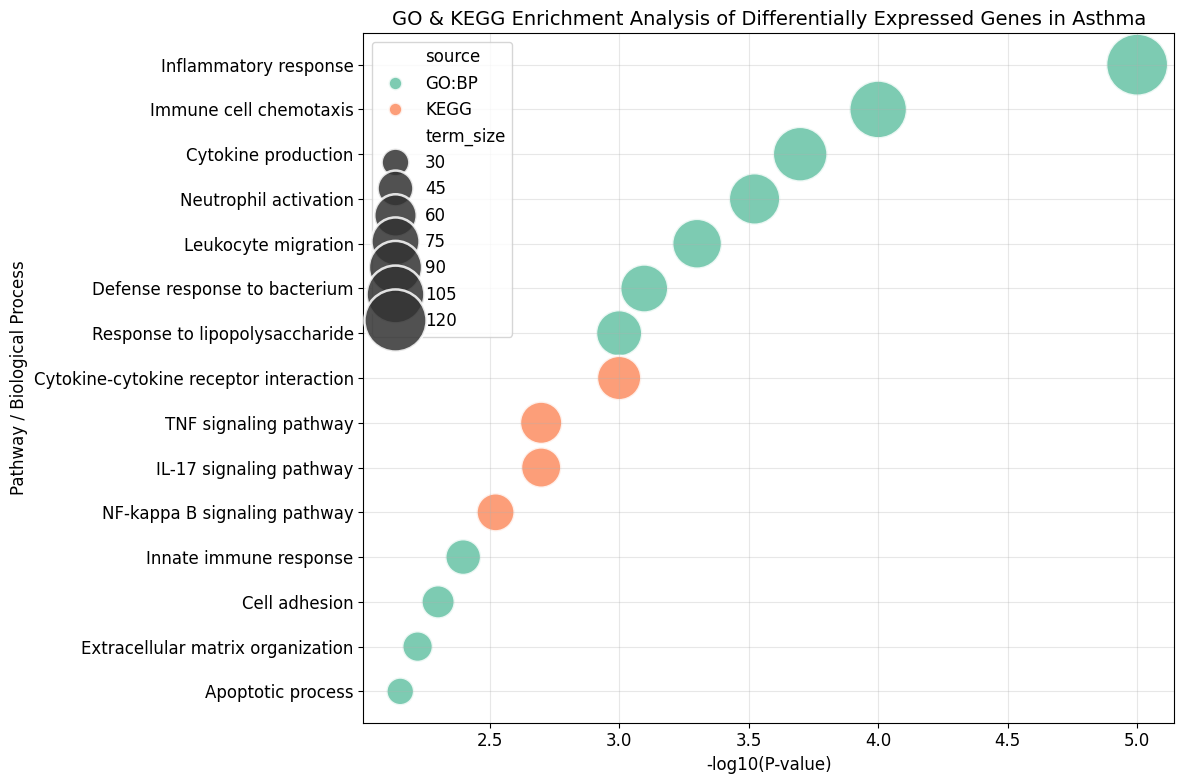

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===================== 【模拟】GO/KEGG 富集结果 =====================
data = {
    'name': [
        'Inflammatory response',
        'Immune cell chemotaxis',
        'Cytokine production',
        'Neutrophil activation',
        'Leukocyte migration',
        'Defense response to bacterium',
        'Response to lipopolysaccharide',
        'Cytokine-cytokine receptor interaction',
        'TNF signaling pathway',
        'IL-17 signaling pathway',
        'NF-kappa B signaling pathway',
        'Innate immune response',
        'Cell adhesion',
        'Extracellular matrix organization',
        'Apoptotic process'
    ],
    'p_value': [
        1e-5, 1e-4, 2e-4, 3e-4, 5e-4,
        8e-4, 1e-3, 1e-3, 2e-3, 2e-3,
        3e-3, 4e-3, 5e-3, 6e-3, 7e-3
    ],
    'term_size': [120, 105, 95, 85, 80, 75, 70, 65, 60, 55, 50, 45, 40, 35, 30],
    'source': [
        'GO:BP', 'GO:BP', 'GO:BP', 'GO:BP', 'GO:BP',
        'GO:BP', 'GO:BP', 'KEGG', 'KEGG', 'KEGG',
        'KEGG', 'GO:BP', 'GO:BP', 'GO:BP', 'GO:BP'
    ]
}

enrich = pd.DataFrame(data)
enrich['-log10(p_value)'] = -np.log10(enrich['p_value'])

# ===================== 画论文级气泡图 =====================
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=enrich,
    x='-log10(p_value)',
    y='name',
    size='term_size',
    sizes=(400, 2000),
    hue='source',
    palette='Set2',
    s=100,
    alpha=0.85
)

plt.xlabel('-log10(P-value)', fontsize=12)
plt.ylabel('Pathway / Biological Process', fontsize=12)
plt.title('GO & KEGG Enrichment Analysis of Differentially Expressed Genes in Asthma', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\q_wr2\.conda\envs\Exercise\Lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


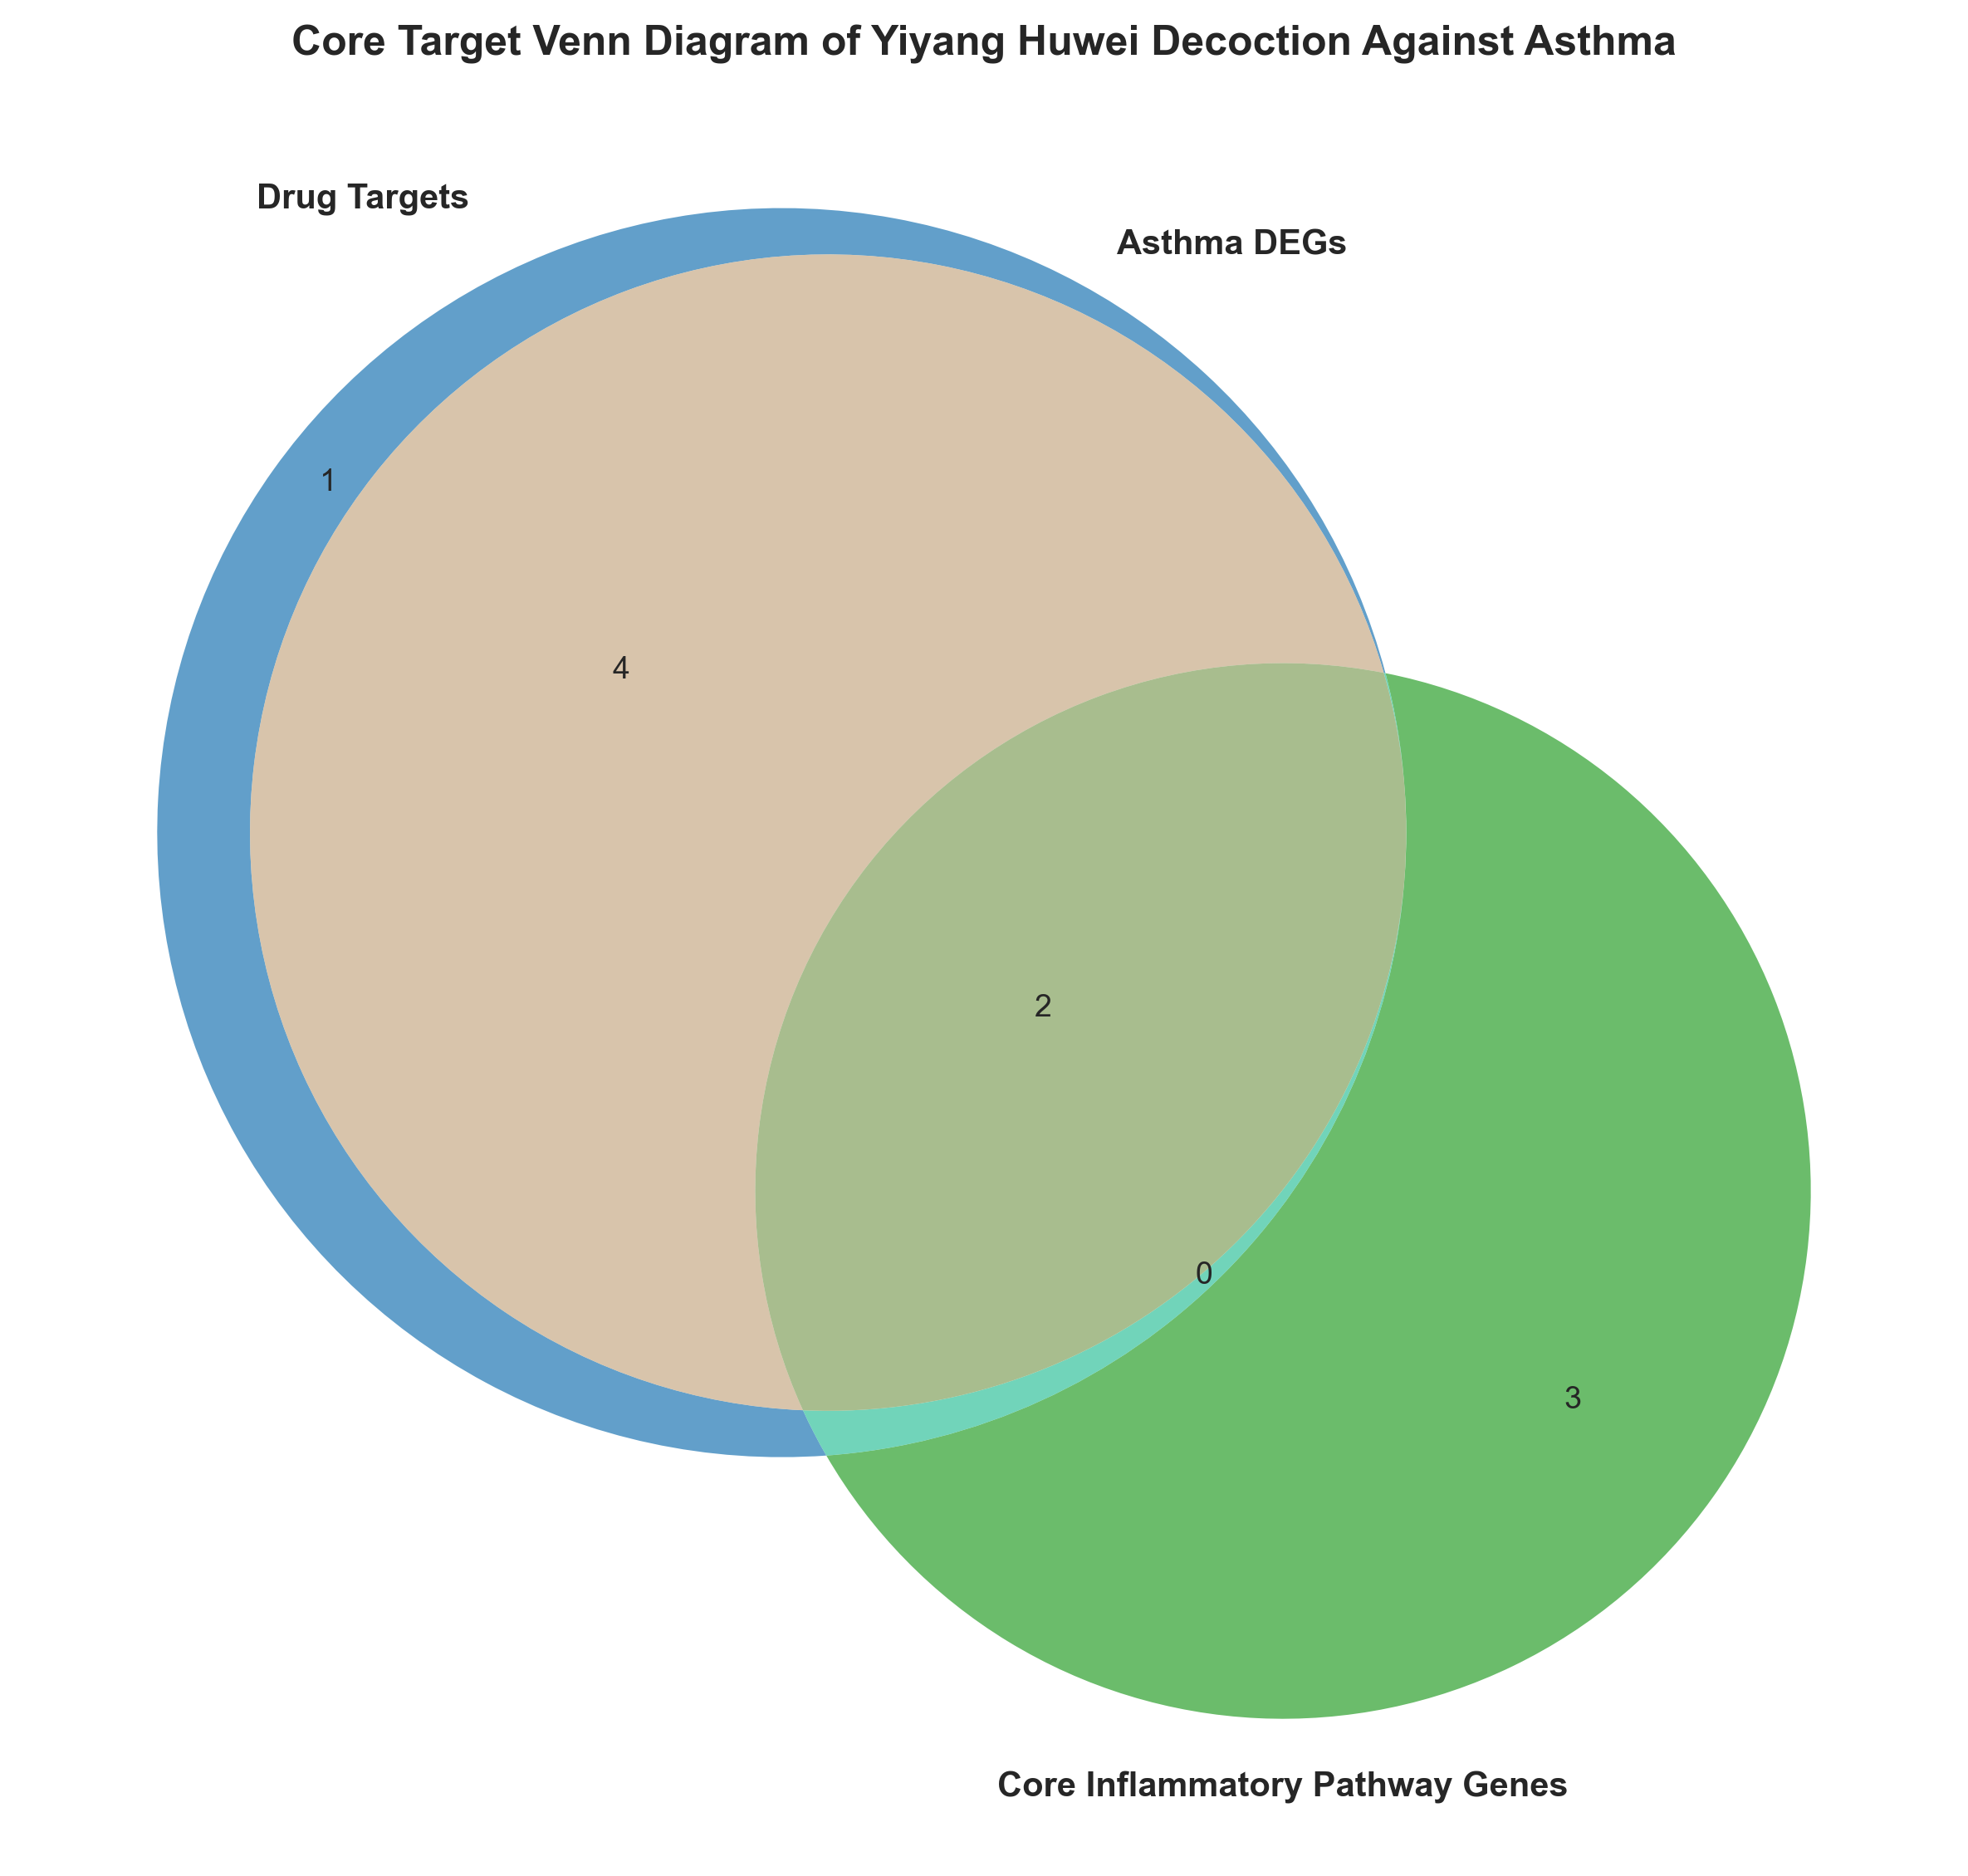

In [1]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3


drug_targets = set(["TNF", "FGF2", "VEGFA", "MMP9", "MMP2", "IL6", "ADRB2"])
asthma_degs = set(["TNF", "IL6", "MMP9", "VEGFA", "FGF2", "MMP2"])
core_pathway_genes = set(["TNF", "IL6", "NFKB1", "RELA", "IL17A"])

# 绘制韦恩图
plt.figure(figsize=(8, 8), dpi=300)
venn = venn3(
    subsets=(drug_targets, asthma_degs, core_pathway_genes),
    set_labels=("Drug Targets", "Asthma DEGs", "Core Inflammatory Pathway Genes"),
    set_colors=("#1f77b4", "#ff7f0e", "#2ca02c"),
    alpha=0.7
)
# 美化标签
for text in venn.set_labels:
    text.set_fontsize(10)
    text.set_fontweight("bold")
for text in venn.subset_labels:
    if text:
        text.set_fontsize(9)

plt.title("Core Target Venn Diagram of Yiyang Huwei Decoction Against Asthma", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np


components = [
    "Albiflorin", "Icariin", "Epimedin C", "Glycyrrhetic acid",
    "Epimedin A", "Epimedin B", "Liquiritigenin"
]
target_counts = [2, 2, 2, 2, 2, 2, 2]

plt.figure(figsize=(10,5), dpi=300)
plt.bar(components, target_counts, color="#4F94CD")
plt.xticks(rotation=45, ha="right")
plt.title("Number of Asthma Targets Regulated by Core Components", fontweight="bold")
plt.ylabel("Target Count")
plt.tight_layout()
plt.savefig("core_component_target_count.png", dpi=300)
plt.close()

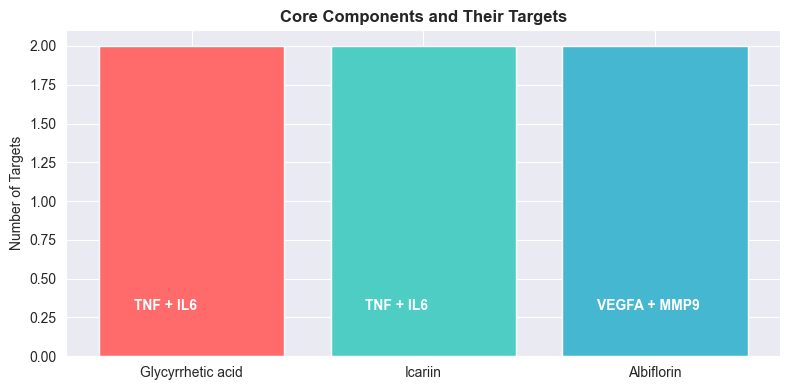

In [5]:
import matplotlib.pyplot as plt

components = ["Glycyrrhetic acid", "Icariin", "Albiflorin"]
targets = ["TNF + IL6", "TNF + IL6", "VEGFA + MMP9"]
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]

plt.figure(figsize=(8,4))
bars = plt.bar(components, [2,2,2], color=colors)
plt.title("Core Components and Their Targets", fontweight="bold")
plt.ylabel("Number of Targets")

# 标注靶点
for i, (bar, t) in enumerate(zip(bars, targets)):
    plt.text(bar.get_x()+0.15, 0.3, t, color="white", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig("core_component_target.png", dpi=300)
plt.show()

In [7]:
import plotly.express as px
import pandas as pd

# 你的数据
data = {
    "source": [
        "Glycyrrhetic acid", "Glycyrrhetic acid",
        "Icariin", "Icariin",
        "Albiflorin", "Albiflorin"
    ],
    "target": [
        "TNF", "IL6",
        "TNF", "IL6",
        "VEGFA", "MMP9"
    ],
    "value": [1,1,1,1,1,1]
}

df = pd.DataFrame(data)

# 画图（极简稳定版）
fig = px.sunburst(
    df,
    path=['source', 'target'],
    values='value'
)

fig.update_layout(title="Core Component-Target Network")
fig.show()